# Analysis Notebook — Conversational Clustering on UCDP GEDEvent 25.1

**Pre-specified analysis plan:** `docs/study_design.md §8`  
**Quality spec:** `docs/quality_spec.md`  
**Input:** `runs/run_log.jsonl` (append-only experiment log)  

**Run `scripts/check_integrity.py` before opening this notebook.**  
All analyses are pre-specified. Any analysis not listed in `study_design.md §8` must be labelled exploratory and post-hoc.

---

### Hypotheses tested here
- **H1 (confirmatory):** Conversational refinement improves Silhouette score vs baseline (Condition B/F2 vs A/F2, Wilcoxon signed-rank, p < 0.05, bootstrap CI excludes 0)
- **H2 (exploratory):** Improvement is larger under F2 than F1
- **H3 (confirmatory):** Oracle–human Spearman ρ > 0.7 with bootstrap CI lower bound > 0.5

### What this notebook does NOT do
- Does not re-draw the sample or re-run clustering
- Does not test metrics not listed in `docs/quality_spec.md §8`
- Does not interpret refused runs as complete runs

In [1]:
import json
import warnings
from pathlib import Path

import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

LOG_PATH = Path('../runs/run_log.jsonl')
assert LOG_PATH.exists(), f'Log file not found: {LOG_PATH}. Run check_integrity.py first.'
print(f'Log file found: {LOG_PATH}')

Log file found: ../runs/run_log.jsonl


## 1. Load and validate the log

In [2]:
records = []
with jsonlines.open(LOG_PATH) as reader:
    for rec in reader:
        records.append(rec)

df_log = pd.DataFrame(records)
print(f'Total records in log: {len(df_log)}')
print(f'Status breakdown:')
print(df_log['status'].value_counts().to_string())

Total records in log: 166
Status breakdown:
status
complete    166


In [3]:
# Keep only complete runs for analysis
# Refused and error runs are reported as data loss — never silently dropped
refused = df_log[df_log['status'] == 'refused']
errors  = df_log[df_log['status'] == 'error']

if len(refused) > 0:
    print(f'⚠ DATA LOSS: {len(refused)} refused runs (Claude safety filter).')
    print('These must be reported in the paper limitations section.')
    print(refused[['run_id', 'condition', 'feature_set', 'seed']].to_string())

if len(errors) > 0:
    print(f'⚠ {len(errors)} error runs — investigate before proceeding.')
    print(errors[['run_id', 'condition', 'feature_set', 'seed']].to_string())

df = df_log[df_log['status'] == 'complete'].copy()
df['silhouette_final'] = pd.to_numeric(df['silhouette_final'])
df['davies_bouldin_final'] = pd.to_numeric(df['davies_bouldin_final'])
print(f'\nComplete runs available for analysis: {len(df)}')
print(df.groupby(['condition', 'feature_set']).size().rename('n_runs').to_string())


Complete runs available for analysis: 166
condition  feature_set
A          F1             30
           F2             30
B          F1             20
           F2             26
C          F1             30
           F2             30


## 2. Descriptive statistics (study_design §8, step 1)

In [4]:
desc = (
    df.groupby(['condition', 'feature_set'])['silhouette_final']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(4)
)
desc.columns = ['mean', 'std', 'min', 'max', 'n']
print('Silhouette score — descriptive statistics')
print('=' * 55)
print(desc.to_string())

Silhouette score — descriptive statistics
                         mean     std     min     max   n
condition feature_set                                    
A         F1           0.9048  0.0007  0.9044  0.9061  30
          F2           0.8936  0.0006  0.8933  0.8950  30
B         F1           0.8495  0.1068  0.5873  0.9448  20
          F2           0.8493  0.0951  0.6449  1.0000  26
C         F1           0.8743  0.1669  0.0000  0.9470  30
          F2           0.8630  0.0533  0.7000  0.9103  30


In [5]:
desc_db = (
    df.groupby(['condition', 'feature_set'])['davies_bouldin_final']
    .agg(['mean', 'std', 'min', 'max'])
    .round(4)
)
desc_db.columns = ['mean', 'std', 'min', 'max']
print('Davies-Bouldin index — descriptive statistics (lower = better)')
print('=' * 55)
print(desc_db.to_string())

Davies-Bouldin index — descriptive statistics (lower = better)
                         mean     std     min     max
condition feature_set                                
A         F1           1.0724  0.0798  0.9310  1.1183
          F2           0.9974  0.0965  0.9550  1.2096
B         F1           0.9638  0.1704  0.6024  1.1500
          F2           0.8395  0.2267  0.0000  1.2096
C         F1              inf     NaN  0.5138     inf
          F2           0.8880  0.1913  0.5830  1.1718


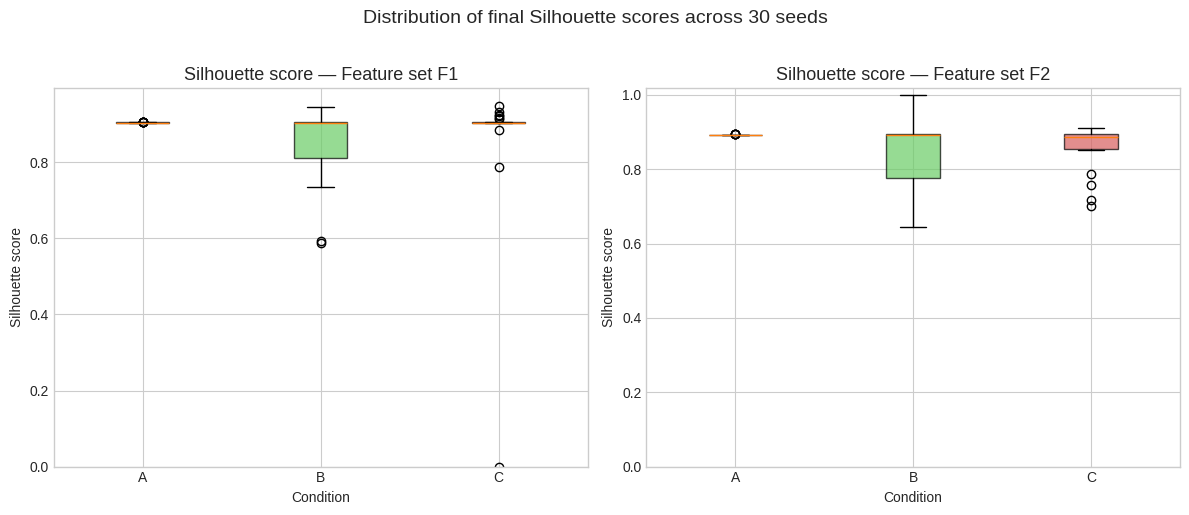

Saved: runs/fig_silhouette_boxplot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fs in zip(axes, ['F1', 'F2']):
    subset = df[df['feature_set'] == fs]
    conditions_present = sorted(subset['condition'].unique())
    if not conditions_present:
        ax.text(0.5, 0.5, f'No data yet for {fs}',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Silhouette score — Feature set {fs}', fontsize=13)
        continue
    data_to_plot = [subset[subset['condition'] == c]['silhouette_final'].values
                    for c in conditions_present]
    bp = ax.boxplot(data_to_plot, tick_labels=conditions_present, patch_artist=True)
    colours = ['#4878CF', '#6ACC65', '#D65F5F']
    for patch, colour in zip(bp['boxes'], colours[:len(conditions_present)]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)
    ax.set_title(f'Silhouette score — Feature set {fs}', fontsize=13)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Silhouette score')
    ax.set_ylim(bottom=0)

plt.suptitle('Distribution of final Silhouette scores across 30 seeds', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../runs/fig_silhouette_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: runs/fig_silhouette_boxplot.png')

## 3. H1 — Wilcoxon signed-rank test (study_design §8, step 2)

**Test:** Condition B/F2 vs Condition A/F2, paired by seed.  
**Decision rule:** One-sided Wilcoxon p < 0.05 AND bootstrap 95% CI on median improvement excludes zero.

In [7]:
def get_paired(cond_1, cond_2, feature_set, metric='silhouette_final'):
    """Return paired arrays (a, b) matched by seed for two conditions."""
    a = df[(df['condition'] == cond_1) & (df['feature_set'] == feature_set)]
    b = df[(df['condition'] == cond_2) & (df['feature_set'] == feature_set)]
    merged = a[['seed', metric]].merge(b[['seed', metric]], on='seed', suffixes=('_a', '_b'))
    return merged[f'{metric}_a'].values, merged[f'{metric}_b'].values, merged['seed'].values

def bootstrap_ci_median_diff(a, b, n_boot=10_000, rng_seed=42):
    """Bootstrap 95% CI on median(b - a)."""
    rng = np.random.default_rng(rng_seed)
    diffs = b - a
    boot_medians = [
        np.median(rng.choice(diffs, size=len(diffs), replace=True))
        for _ in range(n_boot)
    ]
    return np.percentile(boot_medians, [2.5, 97.5])

def matched_pairs_r(stat, n):
    """Effect size r from Wilcoxon W statistic."""
    z = (stat - n*(n+1)/4) / np.sqrt(n*(n+1)*(2*n+1)/24)
    return abs(z) / np.sqrt(n)

# ── H1 test ────────────────────────────────────────────────────────────────
h1_conditions = [('A', 'B'), ('A', 'C')]  # baseline vs each treatment

for cond_baseline, cond_treatment in h1_conditions:
    try:
        sil_a, sil_b, seeds = get_paired(cond_baseline, cond_treatment, 'F2')
    except Exception:
        print(f'Condition {cond_treatment}/F2 not yet available — skipping.')
        continue

    if len(sil_a) < 2:
        print(f'Not enough paired observations for {cond_baseline} vs {cond_treatment}.')
        continue

    diffs = sil_b - sil_a
    stat, p_val = stats.wilcoxon(sil_b, sil_a, alternative='greater')
    ci_low, ci_high = bootstrap_ci_median_diff(sil_a, sil_b)
    r = matched_pairs_r(stat, len(diffs))

    print(f'\n── H1: Condition {cond_treatment}/F2 vs {cond_baseline}/F2 ──')
    print(f'  n paired seeds:       {len(diffs)}')
    print(f'  Median improvement:   {np.median(diffs):+.4f}')
    print(f'  Bootstrap 95% CI:     [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'  Wilcoxon W:           {stat:.1f}')
    print(f'  p-value (one-sided):  {p_val:.4f}')
    print(f'  Effect size r:        {r:.3f}')

    # Decision rule
    confirmatory = (p_val < 0.05) and (ci_low > 0)
    if confirmatory:
        print(f'  ✓ H1 SUPPORTED: p < 0.05 and CI excludes zero.')
    elif p_val < 0.05:
        print(f'  ~ TRENDING: p < 0.05 but CI includes zero — inconclusive.')
    else:
        print(f'  ✗ H1 NOT SUPPORTED: p = {p_val:.4f}')


── H1: Condition B/F2 vs A/F2 ──
  n paired seeds:       26
  Median improvement:   -0.0003
  Bootstrap 95% CI:     [-0.0548, 0.0014]
  Wilcoxon W:           103.0
  p-value (one-sided):  0.9103
  Effect size r:        0.361
  ✗ H1 NOT SUPPORTED: p = 0.9103

── H1: Condition C/F2 vs A/F2 ──
  n paired seeds:       30
  Median improvement:   -0.0065
  Bootstrap 95% CI:     [-0.0307, -0.0014]
  Wilcoxon W:           79.0
  p-value (one-sided):  0.9992
  Effect size r:        0.576
  ✗ H1 NOT SUPPORTED: p = 0.9992


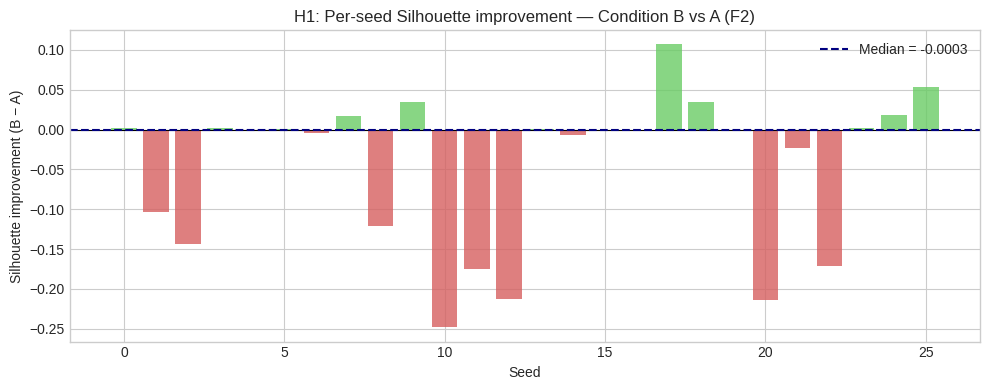

Saved: runs/fig_h1_improvement.png


In [8]:
# Per-seed improvement plot for H1
try:
    sil_a, sil_b, seeds = get_paired('A', 'B', 'F2')
    diffs = sil_b - sil_a

    fig, ax = plt.subplots(figsize=(10, 4))
    colours = ['#6ACC65' if d > 0 else '#D65F5F' for d in diffs]
    ax.bar(seeds, diffs, color=colours, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(np.median(diffs), color='navy', linewidth=1.5,
               linestyle='--', label=f'Median = {np.median(diffs):+.4f}')
    ax.set_xlabel('Seed')
    ax.set_ylabel('Silhouette improvement (B − A)')
    ax.set_title('H1: Per-seed Silhouette improvement — Condition B vs A (F2)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../runs/fig_h1_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: runs/fig_h1_improvement.png')
except Exception as e:
    print(f'Condition B not yet available for H1 plot: {e}')

## 4. H2 — Exploratory: F1 vs F2 improvement (study_design §8, step 3)

**Test:** Is the B−A improvement larger under F2 than F1?  
Mann-Whitney U on per-seed improvement scores.  
**Labelled exploratory — no multiple-comparison correction.**

In [9]:
try:
    sil_a_f1, sil_b_f1, _ = get_paired('A', 'B', 'F1')
    sil_a_f2, sil_b_f2, _ = get_paired('A', 'B', 'F2')

    improvement_f1 = sil_b_f1 - sil_a_f1
    improvement_f2 = sil_b_f2 - sil_a_f2

    u_stat, p_u = stats.mannwhitneyu(improvement_f2, improvement_f1, alternative='greater')

    print('── H2 (EXPLORATORY): F2 improvement vs F1 improvement ──')
    print(f'  Median improvement F1: {np.median(improvement_f1):+.4f}')
    print(f'  Median improvement F2: {np.median(improvement_f2):+.4f}')
    print(f'  Mann-Whitney U:        {u_stat:.1f}')
    print(f'  p-value (one-sided):   {p_u:.4f}')
    print('  ⚠ Exploratory result — no multiple-comparison correction applied.')

    if p_u < 0.05:
        print('  ~ F2 improvement appears larger than F1 improvement.')
    else:
        print('  ~ No clear difference in improvement magnitude between F1 and F2.')
except Exception as e:
    print(f'Condition B not yet available for H2: {e}')

── H2 (EXPLORATORY): F2 improvement vs F1 improvement ──
  Median improvement F1: +0.0000
  Median improvement F2: -0.0003
  Mann-Whitney U:        273.0
  p-value (one-sided):   0.3902
  ⚠ Exploratory result — no multiple-comparison correction applied.
  ~ No clear difference in improvement magnitude between F1 and F2.


## 5. Robustness check — Davies-Bouldin (study_design §8, step 5)

In [10]:
try:
    db_a, db_b, _ = get_paired('A', 'B', 'F2', metric='davies_bouldin_final')
    # For DB: lower is better, so improvement = a - b (treatment should be lower)
    stat_db, p_db = stats.wilcoxon(db_a, db_b, alternative='greater')  # a > b = improvement
    ci_db = bootstrap_ci_median_diff(db_b, db_a)  # CI on a - b

    print('── Robustness check: Davies-Bouldin (lower = better) ──')
    print(f'  Median DB reduction (A − B): {np.median(db_a - db_b):+.4f}')
    print(f'  Bootstrap 95% CI:            [{ci_db[0]:.4f}, {ci_db[1]:.4f}]')
    print(f'  Wilcoxon p (one-sided):      {p_db:.4f}')

    if p_db < 0.05:
        print('  ✓ DB result consistent with Silhouette (both support H1).')
    else:
        print('  ⚠ DB result diverges from Silhouette — discuss in paper.')
except Exception as e:
    print(f'Condition B not yet available for DB robustness check: {e}')

── Robustness check: Davies-Bouldin (lower = better) ──
  Median DB reduction (A − B): +0.0971
  Bootstrap 95% CI:            [0.0190, 0.2520]
  Wilcoxon p (one-sided):      0.0000
  ✓ DB result consistent with Silhouette (both support H1).


## 6. Per-turn trajectory (exploratory, study_design §8, step 6)

Saved: runs/fig_turn_trajectory.png


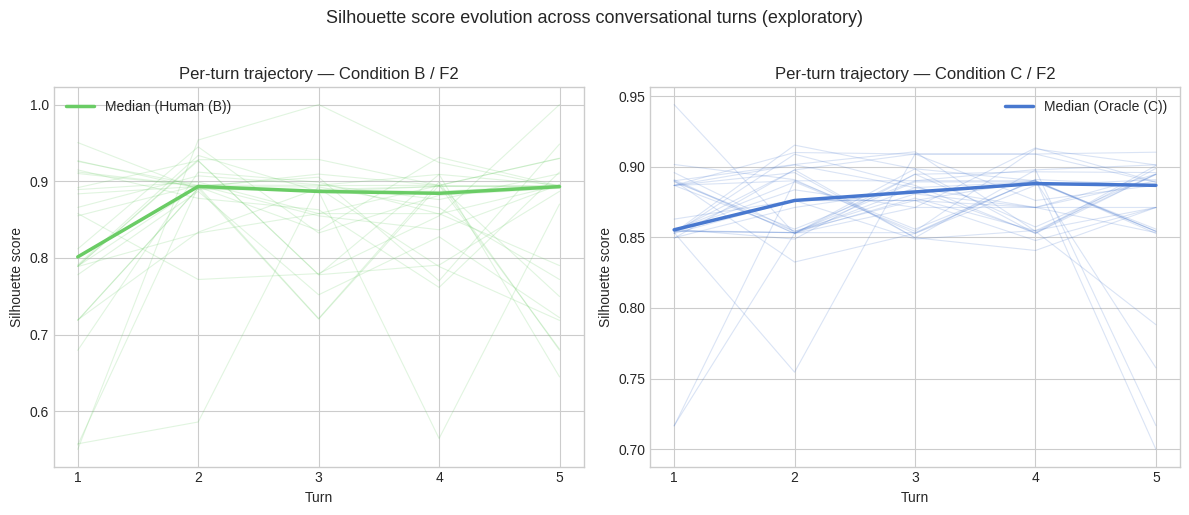

In [11]:
def extract_trajectories(condition, feature_set):
    """Extract per-turn silhouette scores for all seeds in a condition."""
    subset = df[(df['condition'] == condition) & (df['feature_set'] == feature_set)]
    rows = []
    for _, rec in subset.iterrows():
        turns = rec.get('turns', [])
        if not turns:
            continue
        for t in turns:
            rows.append({
                'seed':      rec['seed'],
                'turn':      t['turn'],
                'silhouette': t['silhouette'],
            })
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plotted_any = False

for ax, (cond, label, colour) in zip(axes, [('B', 'Human (B)', '#6ACC65'), ('C', 'Oracle (C)', '#4878CF')]):
    traj = extract_trajectories(cond, 'F2')
    if traj.empty:
        ax.text(0.5, 0.5, f'Condition {cond} not yet run',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Turn trajectory — Condition {cond} / F2')
        continue
    plotted_any = True
    # Plot individual seed trajectories faintly
    for seed, grp in traj.groupby('seed'):
        ax.plot(grp['turn'], grp['silhouette'], color=colour, alpha=0.2, linewidth=0.8)
    # Plot median trajectory boldly
    median_traj = traj.groupby('turn')['silhouette'].median()
    ax.plot(median_traj.index, median_traj.values, color=colour,
            linewidth=2.5, label=f'Median ({label})')
    ax.set_xlabel('Turn')
    ax.set_ylabel('Silhouette score')
    ax.set_title(f'Per-turn trajectory — Condition {cond} / F2')
    ax.set_xticks(range(1, 6))
    ax.legend()

plt.suptitle('Silhouette score evolution across conversational turns (exploratory)', fontsize=13, y=1.02)
plt.tight_layout()
if plotted_any:
    plt.savefig('../runs/fig_turn_trajectory.png', dpi=150, bbox_inches='tight')
    print('Saved: runs/fig_turn_trajectory.png')
plt.show()

## 7. H3 — Oracle–human agreement (study_design §8, step 4)

**Input:** manually collected human ratings CSV and oracle ratings.  
**Decision rule:** Spearman ρ > 0.7 AND bootstrap CI lower bound > 0.5. Cohen's κ ≥ 0.40 required.

This section expects a file `runs/human_ratings.csv` with columns:  
`pair_id, rater_1, rater_2, ..., rater_N`  (values: 'A' or 'B')  
and a file `runs/oracle_ratings.csv` with columns:  
`pair_id, oracle_choice`  (values: 'A' or 'B')

In [12]:
import krippendorff

human_path  = Path('../runs/human_ratings.csv')
oracle_path = Path('../runs/oracle_ratings.csv')

if not human_path.exists() or not oracle_path.exists():
    print('H3 inputs not yet available.')
    print(f'  Expected: {human_path}')
    print(f'  Expected: {oracle_path}')
    print('Run human rating session and oracle evaluation first.')
else:
    # ── Load ratings ─────────────────────────────────────────────────────
    human_df  = pd.read_csv(human_path)
    oracle_df = pd.read_csv(oracle_path)

    rater_cols = [c for c in human_df.columns if c != 'pair_id']
    print(f'Human raters: {len(rater_cols)} ({rater_cols})')
    print(f'Pairs: {len(human_df)}')

    # ── Inter-rater reliability (Krippendorff α) ─────────────────────────
    # Encode A=0, B=1 for krippendorff
    rating_matrix = human_df[rater_cols].replace({'A': 0, 'B': 1}).values.T.tolist()
    alpha = krippendorff.alpha(reliability_data=rating_matrix, level_of_measurement='nominal')

    print(f'\n── Inter-rater reliability ──')
    print(f"  Krippendorff's α: {alpha:.3f}")
    if alpha < 0.20:
        print('  ✗ α < 0.20: Human data unreliable. H3 reported as infeasible.')
    elif alpha < 0.40:
        print('  ⚠ α < 0.40: H3 proceeds with prominent reliability caveat.')
    else:
        print('  ✓ α ≥ 0.40: Acceptable reliability for H3.')

    # ── Majority vote ─────────────────────────────────────────────────────
    def majority_vote(row):
        vals = row[rater_cols].dropna().values
        n_a = (vals == 'A').sum()
        n_b = (vals == 'B').sum()
        if n_a > n_b: return 'A'
        if n_b > n_a: return 'B'
        return 'TIE'

    human_df['majority'] = human_df.apply(majority_vote, axis=1)
    n_ties = (human_df['majority'] == 'TIE').sum()
    print(f'\n  Tied pairs (excluded from ρ): {n_ties}')

    # ── Merge with oracle ─────────────────────────────────────────────────
    merged = human_df[['pair_id', 'majority']].merge(oracle_df, on='pair_id')
    merged = merged[merged['majority'] != 'TIE'].copy()

    human_bin  = (merged['majority'] == 'B').astype(int).values
    oracle_bin = (merged['oracle_choice'] == 'B').astype(int).values
    n_pairs = len(merged)

    # ── Spearman ρ ────────────────────────────────────────────────────────
    rho, p_rho = stats.spearmanr(human_bin, oracle_bin)

    rng = np.random.default_rng(42)
    boot_rhos = []
    for _ in range(10_000):
        idx = rng.choice(n_pairs, size=n_pairs, replace=True)
        r, _ = stats.spearmanr(human_bin[idx], oracle_bin[idx])
        boot_rhos.append(r)
    ci_rho = np.percentile(boot_rhos, [2.5, 97.5])

    # ── Cohen's κ ─────────────────────────────────────────────────────────
    from sklearn.metrics import cohen_kappa_score
    kappa = cohen_kappa_score(human_bin, oracle_bin)

    rng2 = np.random.default_rng(43)
    boot_kappas = []
    for _ in range(10_000):
        idx = rng2.choice(n_pairs, size=n_pairs, replace=True)
        try:
            k = cohen_kappa_score(human_bin[idx], oracle_bin[idx])
            boot_kappas.append(k)
        except Exception:
            pass
    ci_kappa = np.percentile(boot_kappas, [2.5, 97.5])

    print(f"\n── H3: Oracle–human agreement (n={n_pairs} pairs, {n_ties} ties excluded) ──")
    print(f"  Spearman's ρ:       {rho:.3f}  [95% CI: {ci_rho[0]:.3f}, {ci_rho[1]:.3f}]")
    print(f"  Cohen's κ:          {kappa:.3f}  [95% CI: {ci_kappa[0]:.3f}, {ci_kappa[1]:.3f}]")

    h3_rho_ok   = (rho > 0.7) and (ci_rho[0] > 0.5)
    h3_kappa_ok = kappa >= 0.40

    if h3_rho_ok and h3_kappa_ok:
        print('  ✓ H3 SUPPORTED: ρ > 0.7, CI lower bound > 0.5, κ ≥ 0.40.')
    elif h3_rho_ok and not h3_kappa_ok:
        print('  ✗ H3 NOT SUPPORTED: ρ threshold met but κ < 0.40 — marginal distributions may inflate ρ.')
    elif rho > 0.7:
        print('  ~ INCONCLUSIVE: ρ > 0.7 but CI lower bound ≤ 0.5.')
    else:
        print(f'  ✗ H3 NOT SUPPORTED: ρ = {rho:.3f} does not exceed 0.7.')

H3 inputs not yet available.
  Expected: ../runs/human_ratings.csv
  Expected: ../runs/oracle_ratings.csv
Run human rating session and oracle evaluation first.


## 8. Summary table for the paper

In [13]:
print('=' * 65)
print('SUMMARY TABLE — all reported metrics')
print('=' * 65)

summary = (
    df.groupby(['condition', 'feature_set'])
    .agg(
        n          = ('silhouette_final', 'count'),
        sil_mean   = ('silhouette_final', 'mean'),
        sil_std    = ('silhouette_final', 'std'),
        db_mean    = ('davies_bouldin_final', 'mean'),
        db_std     = ('davies_bouldin_final', 'std'),
    )
    .round(4)
)
print(summary.to_string())
print()
print('Figures saved to runs/fig_*.png')
print('Log provenance: see config_hash and prompt_hashes fields in run_log.jsonl')

SUMMARY TABLE — all reported metrics
                        n  sil_mean  sil_std  db_mean  db_std
condition feature_set                                        
A         F1           30    0.9048   0.0007   1.0724  0.0798
          F2           30    0.8936   0.0006   0.9974  0.0965
B         F1           20    0.8495   0.1068   0.9638  0.1704
          F2           26    0.8493   0.0951   0.8395  0.2267
C         F1           30    0.8743   0.1669      inf     NaN
          F2           30    0.8630   0.0533   0.8880  0.1913

Figures saved to runs/fig_*.png
Log provenance: see config_hash and prompt_hashes fields in run_log.jsonl
